In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
import numpy as np
from matplotlib import pyplot as plt
import os
os.system("unset LD_LIBRARY_PATH")

#from GKDG import GaussianKDE
from torch.autograd.functional import jacobian
from sklearn.neighbors import KernelDensity as KD


import os
import argparse
import math

from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torchdiffeq import odeint_adjoint as odeint

from cnf import CNF
from energy_functions import energy_function_1, energy_function_2, energy_function_3, energy_function_4

from data_loader import energygap12_transf
from data_loader import energygap01_transf
from data_loader import nac_veloc
from data_loader import pop_average

In [2]:
##units
scale_t=41.34110546116003  #Time : 1 fs = 41.34110546116003 a.u.
scale_m=1823.1814419193488 #Mass : 1 ram = 1823.1814419193488 a.u.
scale_L=1.8897259885789233 #coord : 1 Astrom = 1.8897259885789233 bohr
scale_E = 1/2625.5   #Energy : 1 kJ/mol = 1/2625.5 hartree 

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = '0'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [4]:
### make data
E0=np.loadtxt('CH2NH2_data//energy0.txt')
E1=np.loadtxt('CH2NH2_data//energy1.txt')
E2=np.loadtxt('CH2NH2_data//energy2.txt')
pop0=np.loadtxt('CH2NH2_data/pop0.txt')
pop1=np.loadtxt('CH2NH2_data//pop1.txt')
pop2=np.loadtxt('CH2NH2_data//pop2.txt')
#DE01=energygap01_transf(E1,E0,pop0)
#DE12=energygap12_transf(E2,E1,pop2)

time=np.linspace(0,100,201)


E0=torch.tensor(E0/27.2114,dtype=float).type(torch.float32).to(device) 
E1=torch.tensor(E1/27.2114,dtype=float).type(torch.float32).to(device) 
E2=torch.tensor(E2/27.2114,dtype=float).type(torch.float32).to(device)

#plt.plot(E1.cpu().detach().numpy())

In [5]:
#E0.type()

In [6]:

nac21=np.array([])
for i in range(100):
    nac=np.loadtxt(f'CH2NH2_data/nac21_{i}.txt')
    veloc=np.loadtxt(f'CH2NH2_data/veloc_{i}.txt')
    nac_t=nac_veloc(nac,veloc,6)
    nac21=np.append(nac21,nac_t)
nac21=nac21.reshape(100,201)
nac21=np.transpose(nac21)
nac21=torch.tensor(nac21).type(torch.float32).to(device)


nac10=np.array([])
for i in range(100):
    nac=np.loadtxt(f'CH2NH2_data/nac10_{i}.txt')
    veloc=np.loadtxt(f'CH2NH2_data/veloc_{i}.txt')
    nac_t=nac_veloc(nac,veloc,6)
    nac10=np.append(nac10,nac_t)
nac10=nac10.reshape(100,201)
nac10=np.transpose(nac10)
nac10=torch.tensor(nac10).type(torch.float32).to(device)




nac20=np.array([])
for i in range(100):
    nac=np.loadtxt(f'CH2NH2_data/nac20_{i}.txt')
    veloc=np.loadtxt(f'CH2NH2_data/veloc_{i}.txt')
    nac_t=nac_veloc(nac,veloc,6)
    nac20=np.append(nac20,nac_t)
nac20=nac20.reshape(100,201)
nac20=np.transpose(nac20)
nac20=torch.tensor(nac20).type(torch.float32).to(device)


In [41]:
#plt.plot(nac21.cpu().detach().numpy())

In [147]:
E_total = torch.tensor(np.loadtxt('./E_total.txt')).type(torch.float32).to(device).unsqueeze(0)

In [149]:
E_total.shape


torch.Size([1, 100])

In [24]:
#DE02 = torch.abs(DE01) + torch.abs(DE12)
#DE02

In [99]:
#Vi_Vj = 
itraj=0
H00 = torch.abs(E0[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[1.,0.,0.],[0.,0.,0.],[0.,0.,0.]]).to(device)
H11 = torch.abs(E1[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,0.],[0.,1.,0.],[0.,0.,0.]]).to(device)
H22 = torch.abs(E2[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,0.],[0.,0.,0.],[0.,0.,1.]]).to(device)
#V01_M
H = H00 + H11 + H22
H = H.type(torch.complex64)

In [100]:
nac01_M = (nac10[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,-1.,0.],[1.,0.,0.],[0.,0.,0.]]).to(device)
nac12_M = (nac21[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,0.],[0.,0.,-1.],[0.,1.,0.]]).to(device)
nac02_M = (nac20[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,-1.],[0.,0.,0.],[1.,0.,0.]]).to(device)
#V01_M
NAC = nac01_M + nac12_M + nac02_M
NAC = NAC.type(torch.complex64)


In [10]:

#Vi_Vj

In [15]:
nstate=3

In [104]:
def propagator(H_t, H_t_Δt, NAC_t, NAC_t_Δt, isub):
    ## @@ H_t and H_t_Δt are MCH Hamilton (no laser)
    ## @@ U_t and U_t_Δt are phase-correctted rotation matix
    ## @@ isub is the index of substep [1 to Nsubstep]
    ## @@ t is the simulation time, (a.u.)
    Δt_small = Δt/Nsubstep
    
    K_t, K_t_Δt = NAC_t, NAC_t_Δt
    
    H_isub = H_t + (H_t_Δt-H_t)*isub/Nsubstep
    K_isub = K_t + (K_t_Δt-K_t)*isub/Nsubstep
    
    
    expH = torch.linalg.matrix_exp(-(H_isub*1j + K_isub)*Δt_small) 
    
    return expH

def Rtotal(H_t, H_t_Δt,NAC_t, NAC_t_Δt):
    
    R_total = torch.eye(nstate).type(torch.complex64).to(device)
    
    for isub in range(1,Nsubstep+1):
        expH = propagator(H_t, H_t_Δt, NAC_t, NAC_t_Δt, isub)
        R_total = torch.matmul(expH,R_total)
    
    return R_total


def update_coefficient(R_total,coefficient):
    
    return torch.matmul(R_total,coefficient)

In [1]:
#R_total = H[0]
#R_total

In [13]:
Nsubstep = 26
list_substep = np.linspace(0,1,Nsubstep)

In [105]:
def Prob_hop(coefficient_t, coefficient_t_Δt, R_total):

    #coefficient_t = torch.tensor([[0.],[0.],[1.]]).type(torch.complex64).to(device)
    #coefficient_t_Δt = torch.tensor([[0.],[0.2],[0.8]]).type(torch.complex64).to(device)
    
    x = torch.transpose(torch.conj(coefficient_t)*coefficient_t,0,1)
    w = torch.transpose(torch.conj(coefficient_t_Δt)*coefficient_t_Δt,0,1)
    
    R_diag = torch.sum(R_total*torch.eye(nstate).type(torch.complex64).to(device),1).unsqueeze(0)
    #R_diag
    j = torch.transpose(coefficient_t_Δt,0,1)*torch.conj(R_diag)*torch.transpose(torch.conj(coefficient_t),0,1)
    
    z = torch.real( torch.transpose(torch.conj(coefficient_t),0,1)*torch.conj(R_total)*coefficient_t_Δt )
    
    y = torch.real(x-j)
    
    PP = (1-torch.real(w/x))*torch.real(z/y)
    PP = torch.where(torch.isnan(PP),torch.full_like(PP,0),PP)
    PP = torch.where(torch.isinf(PP),torch.full_like(PP,0),PP)
    PP = torch.transpose(PP,0,1)*(1-torch.eye(nstate)).to(device)
    
    PP = PP/torch.maximum(torch.sum(PP,1),torch.tensor(1)).unsqueeze(1)
    return PP

In [106]:

float(aaa[0].sum().cpu().detach().numpy())



0.6000000238418579

In [41]:
#(1-tf1.real(w/x))*tf1.real(z/y)
#istate = np.int64([[0],[0],[1]])
#np.int64(np.transpose(istate)*(1-istate))


In [14]:
#pop2[:23,0:1]

In [107]:
Nsubstep = 25

In [203]:
##fssh
istate_pop_all = np.zeros([1,201])

for itraj in range(100):
    

    H00 = torch.abs(E0[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[1.,0.,0.],[0.,0.,0.],[0.,0.,0.]]).to(device)
    H11 = torch.abs(E1[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,0.],[0.,1.,0.],[0.,0.,0.]]).to(device)
    H22 = torch.abs(E2[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,0.],[0.,0.,0.],[0.,0.,1.]]).to(device)
    #V01_M
    H = H00 + H11 + H22
    H = H.type(torch.complex64)
    
    nac01_M = torch.abs(nac10[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,-1.,0.],[1.,0.,0.],[0.,0.,0.]]).to(device)
    nac12_M = torch.abs(nac21[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,0.],[0.,0.,-1.],[0.,1.,0.]]).to(device)
    nac02_M = torch.abs(nac20[:,itraj:itraj+1]).unsqueeze(2)*torch.tensor([[0.,0.,-1.],[0.,0.,0.],[1.,0.,0.]]).to(device)
    #V01_M
    NAC = nac01_M + nac12_M + nac02_M
    NAC = NAC.type(torch.complex64)
    
    
    Δt_fs = 0.5
    Δt = Δt_fs*scale_t
    
    coefficient_init = torch.tensor([[0.],[0.],[1.]]).type(torch.complex64).to(device)
    
    #c = torch.tensor([[0.,0.,1.]]).type(torch.complex64)
    #rho_init = torch.transpose(torch.conj(c),0,1)*c
    #rho_init = rho_init.to(device)
    
    
    istate=2
    istate_pop = np.array([istate])
    coefficient_t = coefficient_init
    E_t = E_total[0,itraj]  ## E_total
    
    for i in range(1,201):
        
        #rho_t_Δt = update_coefficient(rho_t,Vi_Vj[i-1], Vi_Vj[i], nac_ij[i-1], nac_ij[i],list_substep)
        
        R_total = Rtotal(H[i-1], H[i], NAC[i-1], NAC[i])
        coefficient_t_Δt = update_coefficient(R_total,coefficient_t)
        P_ij = Prob_hop(coefficient_t, coefficient_t_Δt, R_total)
        

        rand_num = torch.tensor(0.).uniform_(0,1).to(device)
        #rand_num = torch.tensor(0.).uniform_(0,1).to(device)
        if istate==2:
            
            #if P_ij[2][:1].sum() < rand_num < P_ij[2][:2].sum():
            if rand_num < P_ij[2][:2].sum():
                istate=1
            elif P_ij[2][:1].sum() > rand_num:
                istate=0
            
        
        if istate==1:
            if P_ij[1][:1].sum() > rand_num:
                istate=0
            #elif P_ij[1][:2].sum() < rand_num < P_ij[1][:3].sum():
            #    istate=2

            
        #if istate==0:
            
            #if P_ij[0][:2].sum() > rand_num > P_ij[0][:1].sum():
            #    istate=1
            #elif P_ij[0][:2].sum() < rand_num < P_ij[0][:3].sum():
            #    istate=2
    
        istate_pop = np.append(istate_pop,istate)
        
        
        ## EDC code
        mask_ = (1-torch.eye(nstate)[:,istate:istate+1]).type(torch.float32).to(device)
        ΔE_ab = torch.abs((H[i]).sum(0).unsqueeze(1)-(H[i])[istate,istate])
        c_alpha = coefficient_t_Δt*mask_*torch.exp(-0.5*Δt*ΔE_ab/(1+Constant/(E_t-(H[i])[istate,istate])))
        c_beta = (coefficient_t_Δt/torch.abs(coefficient_t_Δt))*(1-mask_)*torch.sqrt(1-torch.sum(mask_*torch.abs(c_alpha)**2))
        coefficient_t_Δt = c_alpha + c_beta
        
        coefficient_t = coefficient_t_Δt
    #pop_Average += istate_pop
    istate_pop_all = np.concatenate((istate_pop_all, istate_pop.reshape(1,201)),axis=0)
    

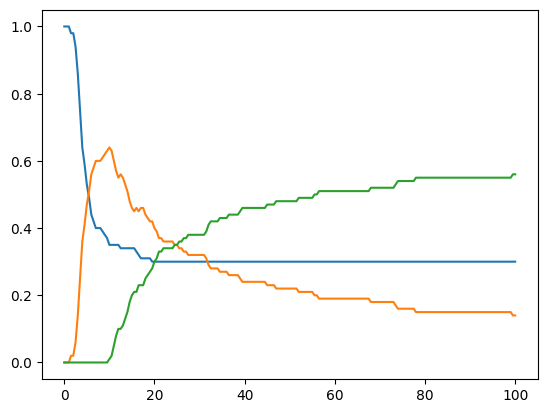

In [204]:
T = np.linspace(0,100,201)

plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==2),axis=1))
plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==1),axis=1))
plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==0),axis=1))

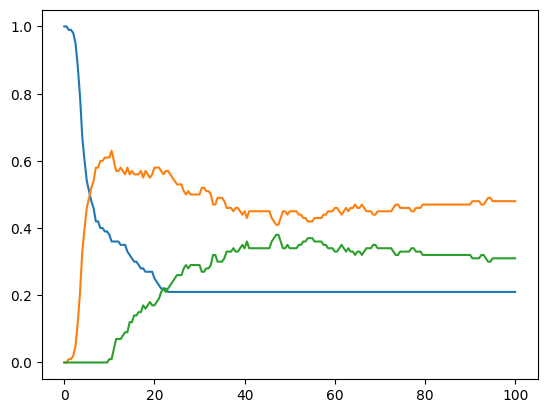

In [198]:
T = np.linspace(0,100,201)

plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==2),axis=1))
plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==1),axis=1))
plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==0),axis=1))

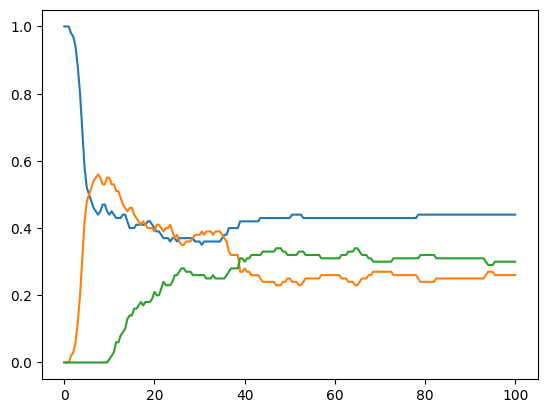

In [194]:
T = np.linspace(0,100,201)

plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==2),axis=1))
plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==1),axis=1))
plt.plot(T,np.mean(np.float32(np.transpose(istate_pop_all[1:])==0),axis=1))

In [196]:
#plt.plot(np.transpose(istate_pop_all[1:])[:,8])


In [174]:
Constant=0.1

In [191]:
## EDC code

mask_ = (1-torch.eye(nstate)[:,istate:istate+1]).type(torch.float32).to(device)
ΔE_ab = torch.abs((H[i]).sum(0).unsqueeze(1)-(H[i])[istate,istate])
c_alpha = coefficient_t_Δt*mask_*torch.exp(-0.5*Δt*ΔE_ab/(1+Constant/(E_t-(H[i])[istate,istate])))
c_beta = (coefficient_t_Δt/torch.abs(coefficient_t_Δt))*(1-mask_)*torch.sqrt(1-torch.sum(mask_*torch.abs(c_alpha)**2))
c_alpha+c_beta

tensor([[-0.0884+0.3140j],
        [ 0.9383+0.0259j],
        [-0.0180-0.1108j]], device='cuda:0')

In [185]:
mask_

tensor([[1.],
        [0.],
        [1.]], device='cuda:0')

In [139]:
#Ekin0_alltrj = np.array([])
#for i in range(100):
#    veloc=np.loadtxt(f'CH2NH2_data/veloc_{i}.txt')
#    Ekin0 = np.sum(0.5*(veloc[:6]**2)*scale_m*np.array([[12],[14],[1],[1],[1],[1]]))
    
#    Ekin0_alltrj = np.append(Ekin0_alltrj, Ekin0)


In [140]:
#E_total = (E2[0:1,:].cpu().detach().numpy() + Ekin0_alltrj.reshape(1,100))

In [141]:
#np.savetxt('./E_total.txt',E_total,delimiter='  ',fmt="%.10f")

In [142]:
#2*torch.real(Δt*rho_t_Δt[1,2]*nac_ij[0][2,1])/torch.real(rho_t_Δt[2,2])

In [40]:
rand_num = torch.tensor(0.).uniform_(0,1).to(device)
rand_num

tensor(0.0548, device='cuda:0')

In [63]:
if P01 > P21 > P02:
    print("aaa")

aaa


tensor(1, device='cuda:0', dtype=torch.int32)

In [129]:
P21

tensor(0.0041, device='cuda:0')